# Inputs for Neural Net
- Type of game played
- Length of game (time and moves)
- Game outcomes
    - Winner
    - Type of outcome
- Move evaluation
    - Variance
    - Mean
    - IQR
    - Next best moves
        - Mean
        - Did they choose the best move?
        - Did they choose the next best move?
- Piece evaluation
    - Number of moves of each piece
    - Captures per piece
    - Number of checks
    - Checks per piece
    - Breakdown per part of the game

# Environment Notes
To get the project to run properly, the python version needs to be set to 3.11. Create a fresh conda envioronment. Run the following commands:
```bash
conda create -n chess python-3.11
conda activate chess
pip install pandas
pip install matplotlib
pip install seaborn
pip install chess
pip install tensorflow
```

In [130]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import chess

# Loading and Cleaning

In [131]:
# Import data and observe shape and columns
chess_data_raw = pd.read_csv("data/games.csv")
print(chess_data_raw.shape)
print(chess_data_raw.columns)
chess_data_raw.head()

chess_data_raw = chess_data_raw[chess_data_raw['turns'] >= 4]

chess_data = chess_data_raw.drop(columns=["id", "white_id", "black_id"])
chess_data = chess_data.dropna()

# Drop all non-rated games for doing rating analysis
chess_data = chess_data[chess_data["rated"] == True]
# Remove rated, created at, and last move at columns
chess_data = chess_data.drop(["rated","created_at","last_move_at"],axis=1)
# Map winner column
chess_data["winner"] = chess_data["winner"].map({"black": -1, "white": 1}).fillna(0)
# Map victory column
chess_data["victory_status"] = chess_data["victory_status"].map({"resign": 0, "mate": 1,"draw": 2, "outoftime": 3})
# Convert moves column to array of moves
chess_data["moves"] = chess_data["moves"].str.split(" ")
# Add column for average player ELO per game
chess_data["game_rating"] = (chess_data["white_rating"] + chess_data["black_rating"]) / 2
# Add column to bucket games by rating 
chess_data["rating_bucket"] = pd.cut(
    chess_data["game_rating"],
    bins=3,
    labels=["low", "medium", "high"]
)

print(chess_data.shape)
chess_data.head()

(20058, 16)
Index(['id', 'rated', 'created_at', 'last_move_at', 'turns', 'victory_status',
       'winner', 'increment_code', 'white_id', 'white_rating', 'black_id',
       'black_rating', 'moves', 'opening_eco', 'opening_name', 'opening_ply'],
      dtype='str')
(15943, 12)


,turns,victory_status,winner,increment_code,white_rating,black_rating,moves,opening_eco,opening_name,opening_ply,game_rating,rating_bucket
1,16,0,-1.0,5+10,1322,1261,"[d4, Nc6, e4, e5, f4, f6, dxe5, fxe5, fxe5, Nx...",B00,Nimzowitsch Defense: Kennedy Variation,4,1291.5,low
2,61,1,1.0,5+10,1496,1500,"[e4, e5, d3, d6, Be3, c6, Be2, b5, Nd2, a5, a4...",C20,King's Pawn Game: Leonardis Variation,3,1498.0,medium
3,61,1,1.0,20+0,1439,1454,"[d4, d5, Nf3, Bf5, Nc3, Nf6, Bf4, Ng4, e3, Nc6...",D02,Queen's Pawn Game: Zukertort Variation,3,1446.5,medium
4,95,1,1.0,30+3,1523,1469,"[e4, e5, Nf3, d6, d4, Nc6, d5, Nb4, a3, Na6, N...",C41,Philidor Defense,5,1496.0,medium
6,33,0,1.0,10+0,1520,1423,"[d4, d5, e4, dxe4, Nc3, Nf6, f3, exf3, Nxf3, N...",D00,Blackmar-Diemer Gambit: Pietrowsky Defense,10,1471.5,medium


In [132]:
# -------------------------------------------------------
# Use Python Chess to get parameters for neural net
# -------------------------------------------------------


def board_analysis(movelist):
    piece_lookup = {
        chess.PAWN: "pawn",
        chess.KNIGHT: "knight",
        chess.BISHOP: "bishop",
        chess.ROOK: "rook",
        chess.QUEEN: "queen",
        chess.KING: "king",
    }
    piece_values = {
        chess.PAWN: 1,
        chess.KNIGHT: 3,
        chess.BISHOP: 3,
        chess.ROOK: 5,
        chess.QUEEN: 9,
        chess.KING: 0,
    }
    colors = ["white", "black"]
    categories = [
        "moves",
        "captures",
        "checks",
        "forks",
        "pins",
        "attacks",
        "defenses",
        "center_control_turns",
    ]
    pieces = ["pawn", "knight", "bishop", "rook", "queen", "king"]
    center_squares = [chess.D4, chess.E4, chess.D5, chess.E5]

    analysis = {
        color: {
            category: {piece: 0 for piece in pieces}
            for category in categories
        }
        for color in colors
    }
    promotion_counts = {color: 0 for color in colors}
    forced_move_counts = {color: 0 for color in colors}
    material_taken = {color: 0 for color in colors}
    material_lost = {color: 0 for color in colors}

    board = chess.Board()

    for san in movelist:
        try:
            move = board.parse_san(san)
        except Exception:
            break

        color = "white" if board.turn == chess.WHITE else "black"
        opponent_color = "black" if color == "white" else "white"
        piece = board.piece_at(move.from_square)

        if piece is None:
            break

        piece_name = piece_lookup[piece.piece_type]
        analysis[color]["moves"][piece_name] += 1

        captured_value = 0
        if board.is_capture(move):
            analysis[color]["captures"][piece_name] += 1
            if board.is_en_passant(move):
                captured_value = piece_values[chess.PAWN]
            else:
                captured_piece = board.piece_at(move.to_square)
                if captured_piece is not None:
                    captured_value = piece_values[captured_piece.piece_type]

        material_taken[color] += captured_value
        material_lost[opponent_color] += captured_value

        board.push(move)

        if board.is_check():
            analysis[color]["checks"][piece_name] += 1

        attacked_enemy_pieces = 0
        defended_friendly_pieces = 0
        pinned_enemy_pieces = 0
        for square in board.attacks(move.to_square):
            target_piece = board.piece_at(square)
            if target_piece is None:
                continue
            if target_piece.color != piece.color:
                attacked_enemy_pieces += 1
                if board.is_pinned(target_piece.color, square):
                    pinned_enemy_pieces += 1
            else:
                defended_friendly_pieces += 1

        analysis[color]["attacks"][piece_name] += attacked_enemy_pieces
        analysis[color]["defenses"][piece_name] += defended_friendly_pieces

        if attacked_enemy_pieces >= 2:
            analysis[color]["forks"][piece_name] += 1

        if pinned_enemy_pieces > 0:
            analysis[color]["pins"][piece_name] += pinned_enemy_pieces

        if move.promotion is not None:
            promotion_counts[color] += 1

        if board.legal_moves.count() == 1:
            forced_move_counts[color] += 1

        for square in center_squares:
            center_piece = board.piece_at(square)
            if center_piece is None:
                continue
            center_color = "white" if center_piece.color == chess.WHITE else "black"
            center_piece_name = piece_lookup[center_piece.piece_type]
            analysis[center_color]["center_control_turns"][center_piece_name] += 1

    flattened_vector = []
    for color in colors:
        for category in categories:
            for piece in pieces:
                flattened_vector.append(analysis[color][category][piece])

    for color in colors:
        flattened_vector.extend([
            promotion_counts[color],
            forced_move_counts[color],
            material_taken[color],
            material_lost[color],
        ])

    return flattened_vector


In [133]:
colors = ["white", "black"]
categories = [
    "moves",
    "captures",
    "checks",
    "forks",
    "pins",
    "attacks",
    "defenses",
    "center_control_turns",
]
pieces = ["pawn", "knight", "bishop", "rook", "queen", "king"]
summary_metrics = ["promotions", "forced_moves", "material_taken", "material_lost"]

neural_net_columns = [
    f"{color}_{category}_{piece}"
    for color in colors
    for category in categories
    for piece in pieces
] + [
    f"{color}_{metric}"
    for color in colors
    for metric in summary_metrics
]

neural_net_columns += [
    "white_elo",
    "black_elo",
    "winner",
    "total_turns",
    "white_turns",
    "black_turns",
    "idx"
]

neural_net_rows = []

for idx, row in chess_data.iterrows():
    total_turns = row["turns"]
    white_turns = (total_turns + 1) // 2
    black_turns = total_turns // 2

    board_analysis_row = board_analysis(row["moves"])
    board_analysis_row += [
        row["white_rating"],
        row["black_rating"],
        row["winner"],
        total_turns,
        white_turns,
        black_turns,
        idx
    ]
    neural_net_rows.append(board_analysis_row)

neural_net_input = pd.DataFrame(neural_net_rows, columns=neural_net_columns)
neural_net_input.describe()


,white_moves_pawn,white_moves_knight,white_moves_bishop,white_moves_rook,white_moves_queen,white_moves_king,white_captures_pawn,white_captures_knight,white_captures_bishop,white_captures_rook,...,black_forced_moves,black_material_taken,black_material_lost,white_elo,black_elo,winner,total_turns,white_turns,black_turns,idx
count,15943.000000,15943.00000,15943.000000,15943.000000,15943.000000,15943.000000,15943.000000,15943.000000,15943.000000,15943.000000,...,15943.000000,15943.000000,15943.000000,15943.00000,15943.000000,15943.000000,15943.000000,15943.000000,15943.000000,15943.000000
mean,8.607288,5.57831,4.966067,4.442828,4.010977,4.032052,1.841247,1.363984,1.430095,1.172803,...,0.353008,20.199272,20.374020,1599.90949,1596.395660,0.041147,62.756758,31.637521,31.119237,10121.965502
std,4.381908,3.43769,3.048665,5.252713,3.749370,5.677335,1.375202,1.241930,1.195479,1.490381,...,0.908748,11.310281,11.261918,282.71278,287.500823,0.976612,33.240935,16.615902,16.628786,5789.764497
min,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,784.00000,789.000000,-1.000000,4.000000,2.000000,2.000000,1.000000
25%,5.000000,3.00000,3.000000,1.000000,2.000000,1.000000,1.000000,0.000000,1.000000,0.000000,...,0.000000,11.000000,11.000000,1399.00000,1393.000000,-1.000000,39.000000,20.000000,19.000000,5159.500000
50%,8.000000,5.00000,4.000000,3.000000,3.000000,2.000000,2.000000,1.000000,1.000000,1.000000,...,0.000000,20.000000,20.000000,1579.00000,1576.000000,0.000000,57.000000,29.000000,28.000000,10047.000000
75%,11.000000,7.00000,6.000000,6.000000,5.000000,5.000000,3.000000,2.000000,2.000000,2.000000,...,0.000000,29.000000,30.000000,1795.00000,1793.000000,1.000000,81.000000,41.000000,40.000000,15223.500000
max,35.000000,59.00000,44.000000,83.000000,41.000000,74.000000,8.000000,11.000000,11.000000,9.000000,...,16.000000,55.000000,55.000000,2622.00000,2588.000000,1.000000,349.000000,175.000000,174.000000,20057.000000


# Nueral Network Development and Design
- Experiment with multiple types of models
- Use smaller data to test
- Find which performs the best
- Train the best performing model using large data

## Import Tensorflow and Relevant Libraries
- Using tensorflow because it is flexible and fast
- It will allow us to process the relatively large dataset (13k rows)

In [134]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Model 1
- Inputs:
    - Action counters (checks, forks, pins, attacks, defenses, moves, and center-control turns per piece per color)
    - Game-level counters (promotions, forced moves, and material taken/lost per color)
    - No centipawn data

- Question: Can ELO be predicted without stockfish centipawn calculation and purely based off of board state and piece statistics?

In [135]:
# ==============================
# Seperate data into X and y
# ==============================

feature_cols = [col for col in neural_net_input.columns if col not in ['white_elo', 'black_elo']]
target_cols = ['white_elo', 'black_elo']

X = neural_net_input[feature_cols].values.astype(np.float32)
y = neural_net_input[target_cols].values.astype(np.float32)

# ============================================================
# Split data into test, train, and validation
# ============================================================

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42
)

# ===================================
# Create normalization layer (scaling)
# ===================================

normalizer = layers.Normalization(axis=-1)
normalizer.adapt(X_train)

# ==============================
# Build model
# ==============================
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    normalizer,
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(2)
])


model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=[keras.metrics.MeanAbsoluteError()]
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True
    )
]

# ==============================
# Train
# ==============================
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

# ==============================
# Evaluate
# ==============================
pred = model.predict(X_test)

white_mae = mean_absolute_error(y_test[:, 0], pred[:, 0])
black_mae = mean_absolute_error(y_test[:, 1], pred[:, 1])

white_rmse = np.sqrt(mean_squared_error(y_test[:, 0], pred[:, 0]))
black_rmse = np.sqrt(mean_squared_error(y_test[:, 1], pred[:, 1]))

print(f"White ELO MAE:  {white_mae:.2f}")
print(f"Black ELO MAE:  {black_mae:.2f}")
print(f"White ELO RMSE: {white_rmse:.2f}")
print(f"Black ELO RMSE: {black_rmse:.2f}")

Epoch 1/200
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 651us/step - loss: 948479.4375 - mean_absolute_error: 788.0703 - val_loss: 195230.6875 - val_mean_absolute_error: 347.7385
Epoch 2/200
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 470us/step - loss: 135876.9375 - mean_absolute_error: 289.9558 - val_loss: 122057.6172 - val_mean_absolute_error: 275.0668
Epoch 3/200
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 466us/step - loss: 103317.5938 - mean_absolute_error: 253.4597 - val_loss: 105401.2734 - val_mean_absolute_error: 256.2641
Epoch 4/200
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 477us/step - loss: 91461.3516 - mean_absolute_error: 238.4753 - val_loss: 95616.6406 - val_mean_absolute_error: 244.3021
Epoch 5/200
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 495us/step - loss: 83823.8047 - mean_absolute_error: 229.2179 - val_loss: 90413.5234 - val_mean_absolute_error: 237.2010
Epoch 6/200
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 484us/step - loss: 78802.0625 - mean_absolute_error: 222.6861 - val_loss: 85285.2422 - val_mean_absolute_error: 231.2134
Epoc

# Analysis
This model performed quite poorly. The mean error was over 200, which is not ideal for ELO. ELO ranges from around 100 - ~3400. The middle 50% of players in this dataset are within 1400 - 1800. This means that our error is too large to accurately guess ELO.

Conclusion: ELO cannot be accurately guessed purely by the strategy statistics calculated for the model. ...

# Neural Net Using Buckets Instead of Regression
- Buckets for classification are high, medium, and low ELO
- Low: <1400
- Medium: 1400-1800
- High: >1800

In [136]:
# ==============================
# Create logical rating buckets
# ==============================
from sklearn.metrics import accuracy_score, classification_report

neural_net_input["average_elo"] = neural_net_input[["white_elo", "black_elo"]].mean(axis=1)
bucket_bins = [0, 1400, 1800, np.inf]
bucket_labels = ["low", "medium", "high"]
neural_net_input["rating_bucket"] = pd.cut(
    neural_net_input["average_elo"],
    bins=bucket_bins,
    labels=bucket_labels,
    include_lowest=True,
    right=False
)

# ==============================
# Prepare bucket classification data
# ==============================
bucket_feature_cols = [
    col for col in neural_net_input.columns
    if col not in ["white_elo", "black_elo", "average_elo", "rating_bucket"]
]
bucket_to_int = {label: idx for idx, label in enumerate(bucket_labels)}

X_bucket = neural_net_input[bucket_feature_cols].values.astype(np.float32)
y_bucket = neural_net_input["rating_bucket"].map(bucket_to_int).astype(np.int32).values

X_bucket_train_full, X_bucket_test, y_bucket_train_full, y_bucket_test = train_test_split(
    X_bucket, y_bucket, test_size=0.15, random_state=42, stratify=y_bucket
)

X_bucket_train, X_bucket_val, y_bucket_train, y_bucket_val = train_test_split(
    X_bucket_train_full,
    y_bucket_train_full,
    test_size=0.15,
    random_state=42,
    stratify=y_bucket_train_full
)

# ===================================
# Create normalization layer (scaling)
# ===================================
bucket_normalizer = layers.Normalization(axis=-1)
bucket_normalizer.adapt(X_bucket_train)

# ==============================
# Build bucket classifier
# ==============================
bucket_model = keras.Sequential([
    keras.Input(shape=(X_bucket_train.shape[1],)),
    bucket_normalizer,
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(len(bucket_labels), activation='softmax')
])

bucket_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

bucket_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True
    )
]

bucket_history = bucket_model.fit(
    X_bucket_train, y_bucket_train,
    validation_data=(X_bucket_val, y_bucket_val),
    epochs=200,
    batch_size=32,
    callbacks=bucket_callbacks,
    verbose=1
)

bucket_pred_probs = bucket_model.predict(X_bucket_test, verbose=0)
bucket_pred = np.argmax(bucket_pred_probs, axis=1)
bucket_accuracy = accuracy_score(y_bucket_test, bucket_pred)

print(f"Bucket accuracy: {bucket_accuracy:.3f}")
print(classification_report(y_bucket_test, bucket_pred, target_names=bucket_labels))


Epoch 1/200
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 666us/step - accuracy: 0.5289 - loss: 0.9676 - val_accuracy: 0.5411 - val_loss: 0.9228
Epoch 2/200
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 485us/step - accuracy: 0.5637 - loss: 0.9029 - val_accuracy: 0.5435 - val_loss: 0.9204
Epoch 3/200
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 478us/step - accuracy: 0.5800 - loss: 0.8707 - val_accuracy: 0.5519 - val_loss: 0.9211
Epoch 4/200
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 476us/step - accuracy: 0.6024 - loss: 0.8378 - val_accuracy: 0.5524 - val_loss: 0.9126
Epoch 5/200
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 477us/step - accuracy: 0.6220 - loss: 0.8053 - val_accuracy: 0.5539 - val_loss: 0.9427
Epoch 6/200
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 478us/step - accuracy: 0.6460 - loss: 0.7686 - val_accuracy: 0.5627 - val_loss: 0.9478
Epoch 7/200
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 475us/step - accuracy: 0.6676 - loss: 0.7275 - val_accuracy: 0.5514 - val_loss: 0.9735
Epoch 8/200
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 478us/step - accuracy: 0.6947 - loss: 0

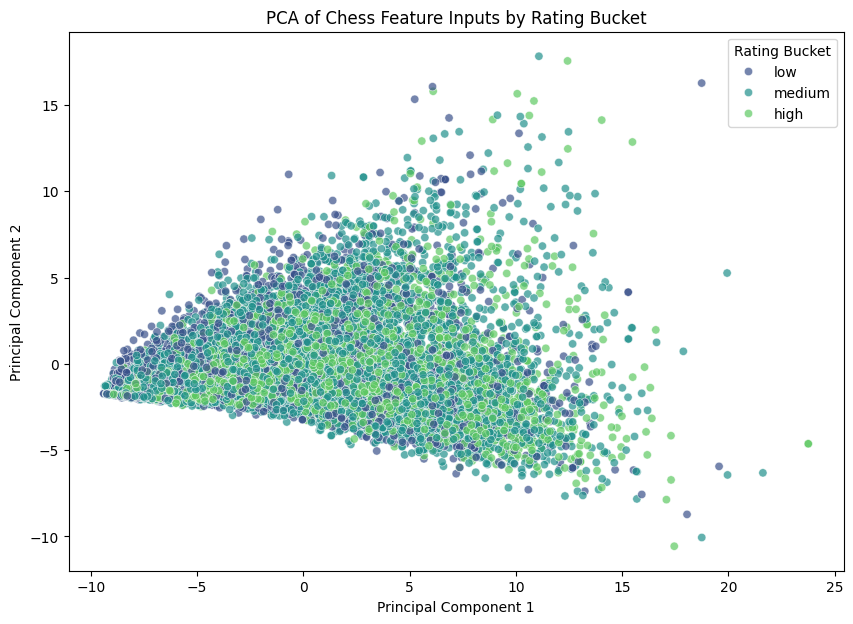

In [137]:
# ==============================
# PCA visualization
# ==============================
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca_scaler = StandardScaler()
X_bucket_scaled = pca_scaler.fit_transform(X_bucket)

pca = PCA(n_components=2, random_state=42)
X_bucket_pca = pca.fit_transform(X_bucket_scaled)

pca_df = pd.DataFrame({
    "PC1": X_bucket_pca[:, 0],
    "PC2": X_bucket_pca[:, 1],
    "rating_bucket": neural_net_input["rating_bucket"].astype(str)
})

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="rating_bucket",
    palette="viridis",
    alpha=0.7
)
plt.title("PCA of Chess Feature Inputs by Rating Bucket")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Rating Bucket")
plt.show()


# Centipawn Model
- Data processing
- Neural network

In [138]:
import ast

# ==============================
# Data processing
# ==============================

centipawn_data = pd.read_csv("centipawn/centipawn_data_depth_12.csv")

# Clamp values (stockfish provided very high values 100000 and -100000 when checkmate was soon)
centipawn_data["centipawn"] = centipawn_data["centipawn"].apply(ast.literal_eval)
centipawn_data["centipawn"] = centipawn_data["centipawn"].apply(
    lambda values: [max(-1000, min(1000, value)) for value in values]
)

# Sort centipawn by color
centipawn_data["white_centipawn"] = centipawn_data["centipawn"].apply(lambda x: x[::2])
centipawn_data["black_centipawn"] = centipawn_data["centipawn"].apply(lambda x: x[1::2])

# Combine centipawn data with board-analysis features using the explicit index columns
neural_net_with_centipawn = neural_net_input.merge(
    centipawn_data,
    left_on="idx",
    right_on="index",
    how="inner"
)

centipawn_vector_input = neural_net_with_centipawn[neural_net_with_centipawn["total_turns"] >= 60]

centipawn_vector_input = centipawn_vector_input[["white_centipawn", "black_centipawn", "white_elo", "black_elo"]]
centipawn_vector_input

,white_centipawn,black_centipawn,white_elo,black_elo
1,"[39, 42, 25, 18, 70, 73, 260, 506, 571, 552, 5...","[-38, 15, -6, -14, -46, -84, -268, -504, -530,...",1496,1500
2,"[43, 37, 48, 0, 89, 133, 172, 232, 382, 437, 5...","[-34, -32, 13, -5, -69, -70, -105, -199, -262,...",1439,1454
3,"[40, 45, 74, 91, 117, 115, 111, 82, 45, -75, -...","[-45, -43, -72, -88, -118, -115, -82, -43, 55,...",1523,1469
5,"[47, 46, 32, 114, 53, 51, 44, 15, 10, 1, -24, ...","[-47, 12, -33, -58, -51, -41, -14, -2, -3, 21,...",1439,1392
6,"[36, 76, 82, 89, 180, 175, 59, 159, 184, 106, ...","[-47, -73, -81, -92, -184, -66, -55, -153, -77...",1381,1209
...,...,...,...,...
15930,"[43, 47, 64, 105, 75, 5, -21, 89, 19, -26, -27...","[-44, -40, -53, -74, -8, 21, 21, 37, 28, 26, 4...",1246,1201
15932,"[40, 85, 45, 90, -4, -2, -64, -392, -17, -1, 1...","[-39, -29, -50, -2, 11, 366, 356, 386, 3, 5, -...",1222,1262
15939,"[43, 64, 132, 111, 8, 23, 15, 18, 21, -28, 82,...","[-43, -48, 2, -9, -2, -4, -17, -15, 74, 22, 26...",1233,1196
15941,"[42, 61, 66, -123, -121, -45, -62, -122, -154,...","[-40, -69, 120, 119, 130, 93, 120, 142, 213, 2...",1360,1227


In [139]:
# ==============================
# Flatten first 30 centipawn moves per side
# ==============================
centipawn_vector_input = centipawn_vector_input[
    (centipawn_vector_input["white_centipawn"].apply(len) >= 30) &
    (centipawn_vector_input["black_centipawn"].apply(len) >= 30)
].copy()

white_cp_columns = [f"white_move_{i + 1}" for i in range(30)]
black_cp_columns = [f"black_move_{i + 1}" for i in range(30)]

white_cp_df = pd.DataFrame(
    centipawn_vector_input["white_centipawn"].apply(lambda moves: moves[:30]).tolist(),
    columns=white_cp_columns,
    index=centipawn_vector_input.index
)

black_cp_df = pd.DataFrame(
    centipawn_vector_input["black_centipawn"].apply(lambda moves: moves[:30]).tolist(),
    columns=black_cp_columns,
    index=centipawn_vector_input.index
)

centipawn_flat_input = pd.concat(
    [
        white_cp_df,
        black_cp_df,
        centipawn_vector_input[["white_elo", "black_elo"]]
    ],
    axis=1
)

centipawn_flat_input.head()

# ==============================
# Prepare data for dense neural net
# ==============================
cp_feature_cols = white_cp_columns + black_cp_columns
cp_target_cols = ["white_elo", "black_elo"]

X_cp = centipawn_flat_input[cp_feature_cols].values.astype(np.float32)
y_cp = centipawn_flat_input[cp_target_cols].values.astype(np.float32)

X_cp_train_full, X_cp_test, y_cp_train_full, y_cp_test = train_test_split(
    X_cp, y_cp, test_size=0.15, random_state=42
)

X_cp_train, X_cp_val, y_cp_train, y_cp_val = train_test_split(
    X_cp_train_full, y_cp_train_full, test_size=0.15, random_state=42
)

# ===================================
# Create normalization layer (scaling)
# ===================================
cp_normalizer = layers.Normalization(axis=-1)
cp_normalizer.adapt(X_cp_train)

# ==============================
# Build dense centipawn model
# ==============================
cp_model = keras.Sequential([
    keras.Input(shape=(60,)),
    cp_normalizer,
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(2)
])

cp_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=[keras.metrics.MeanAbsoluteError()]
)

cp_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )
]

cp_history = cp_model.fit(
    X_cp_train, y_cp_train,
    validation_data=(X_cp_val, y_cp_val),
    epochs=200,
    batch_size=32,
    callbacks=cp_callbacks,
    verbose=1
)

# ==============================
# Evaluate
# ==============================
cp_pred = cp_model.predict(X_cp_test, verbose=0)

cp_white_mae = mean_absolute_error(y_cp_test[:, 0], cp_pred[:, 0])
cp_black_mae = mean_absolute_error(y_cp_test[:, 1], cp_pred[:, 1])

cp_white_rmse = np.sqrt(mean_squared_error(y_cp_test[:, 0], cp_pred[:, 0]))
cp_black_rmse = np.sqrt(mean_squared_error(y_cp_test[:, 1], cp_pred[:, 1]))

print(f"White ELO MAE:  {cp_white_mae:.2f}")
print(f"Black ELO MAE:  {cp_black_mae:.2f}")
print(f"White ELO RMSE: {cp_white_rmse:.2f}")
print(f"Black ELO RMSE: {cp_black_rmse:.2f}")


Epoch 1/200
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 929us/step - loss: 1858450.8750 - mean_absolute_error: 1252.4921 - val_loss: 1096374.2500 - val_mean_absolute_error: 913.6203
Epoch 2/200
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 533us/step - loss: 849505.1250 - mean_absolute_error: 782.7180 - val_loss: 567517.9375 - val_mean_absolute_error: 631.1475
Epoch 3/200
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 547us/step - loss: 384216.7188 - mean_absolute_error: 500.4184 - val_loss: 217704.9062 - val_mean_absolute_error: 372.4092
Epoch 4/200
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 575us/step - loss: 165067.0938 - mean_absolute_error: 320.3066 - val_loss: 124434.4766 - val_mean_absolute_error: 279.0604
Epoch 5/200
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 546us/step - loss: 117427.3047 - mean_absolute_error: 270.3654 - val_loss: 97612.6562 - val_mean_absolute_error: 249.2565
Epoch 6/200
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 531us/step - loss: 96156.8047 - mean_absolute_error: 246.4934 - val_loss: 84322.8203 - val_mean_absolute_error: 232.207

# Adding summary statistics to centipawn data

In [152]:
white_avg = []
white_std = []
white_median = []
white_max = []
white_min = []

black_avg = []
black_std = []
black_median = []
black_max = []
black_min = []

for idx, row in centipawn_data.iterrows():
    white_cp = row["white_centipawn"]
    white_avg.append(np.mean(white_cp))
    white_std.append(np.std(white_cp))
    white_median.append(np.median(white_cp))
    white_max.append(np.max(white_cp))
    white_min.append(np.min(white_cp))

    black_cp = row["black_centipawn"]
    black_avg.append(np.mean(black_cp))
    black_std.append(np.std(black_cp))
    black_median.append(np.median(black_cp))
    black_max.append(np.max(black_cp))
    black_min.append(np.min(black_cp))

centipawn_data["white_avg"] = white_avg
centipawn_data["white_std"] = white_std
centipawn_data["white_median"] = white_median
centipawn_data["white_max"] = white_max
centipawn_data["white_min"] = white_min

centipawn_data["black_avg"] = black_avg
centipawn_data["black_std"] = black_std
centipawn_data["black_median"] = black_median
centipawn_data["black_max"] = black_max
centipawn_data["black_min"] = black_min

# Combine centipawn data with board-analysis features using the explicit index columns
summary_input = neural_net_input.merge(
    centipawn_data,
    left_on="idx",
    right_on="index",
    how="inner"
)

summary_input = pd.concat(
    [
        white_cp_df,
        black_cp_df,
        summary_input[["white_avg", "white_std", "white_median", "white_max", "white_min", "white_elo", "black_avg", "black_std", "black_median", "black_max", "black_min", "black_elo"]]
    ],
    axis=1
)

summary_input

,white_move_1,white_move_2,white_move_3,white_move_4,white_move_5,white_move_6,white_move_7,white_move_8,white_move_9,white_move_10,...,white_median,white_max,white_min,white_elo,black_avg,black_std,black_median,black_max,black_min,black_elo
1,39.0,42.0,25.0,18.0,70.0,73.0,260.0,506.0,571.0,552.0,...,1000.0,1000,18,1496,-678.000000,383.210038,-945.5,15,-1000,1500
2,43.0,37.0,48.0,0.0,89.0,133.0,172.0,232.0,382.0,437.0,...,843.0,1000,0,1439,-615.333333,395.140172,-731.5,13,-1000,1454
3,40.0,45.0,74.0,91.0,117.0,115.0,111.0,82.0,45.0,-75.0,...,622.0,1000,-76,1523,-463.787234,336.742906,-605.0,80,-1000,1469
5,47.0,46.0,32.0,114.0,53.0,51.0,44.0,15.0,10.0,1.0,...,-18.0,114,-1000,1439,245.909091,311.271426,76.0,1000,-58,1392
6,36.0,76.0,82.0,89.0,180.0,175.0,59.0,159.0,184.0,106.0,...,15.5,1000,-610,1381,-89.694915,556.372977,17.0,669,-1000,1209
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15935,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,16.0,45,4,1243,-7.750000,15.319514,-1.5,5,-33,1142
15936,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-271.0,178,-1000,1237,419.206897,272.987985,431.0,1000,-38,1231
15937,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,195.0,599,43,1219,-155.444444,100.283056,-146.0,-36,-409,1250
15938,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,26.0,71,-367,1691,80.166667,158.610021,-12.5,380,-52,1220


# Combining the methods
- Take both strategy statistics and game evaluation to provide more accurate ELO prediction

In [141]:
combined_neural_net_input = pd.concat(
    [
        white_cp_df,
        black_cp_df,
        neural_net_with_centipawn[neural_net_with_centipawn["total_turns"] >= 60]
    ],
    axis=1
)

combined_neural_net_input = combined_neural_net_input.drop(columns=["centipawn", "black_centipawn", "white_centipawn", "idx", "index", "rating_bucket", "total_turns", "white_turns", "black_turns", "average_elo"])


In [142]:
# ==============================
# Prepare combined data for dense neural net
# ==============================
combined_feature_cols = [col for col in combined_neural_net_input.columns if col not in ["white_elo", "black_elo"]]
combined_target_cols = ["white_elo", "black_elo"]

X_combined = combined_neural_net_input[combined_feature_cols].values.astype(np.float32)
y_combined = combined_neural_net_input[combined_target_cols].values.astype(np.float32)

X_combined_train_full, X_combined_test, y_combined_train_full, y_combined_test = train_test_split(
    X_combined, y_combined, test_size=0.15, random_state=42
)

X_combined_train, X_combined_val, y_combined_train, y_combined_val = train_test_split(
    X_combined_train_full, y_combined_train_full, test_size=0.15, random_state=42
)

# ===================================
# Create normalization layer (scaling)
# ===================================
combined_normalizer = layers.Normalization(axis=-1)
combined_normalizer.adapt(X_combined_train)

# ==============================
# Build combined model
# ==============================
combined_model = keras.Sequential([
    keras.Input(shape=(X_combined_train.shape[1],)),
    combined_normalizer,
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(2)
])

combined_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=[keras.metrics.MeanAbsoluteError()]
)

combined_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )
]

combined_history = combined_model.fit(
    X_combined_train, y_combined_train,
    validation_data=(X_combined_val, y_combined_val),
    epochs=200,
    batch_size=32,
    callbacks=combined_callbacks,
    verbose=1
)

# ==============================
# Evaluate
# ==============================
combined_pred = combined_model.predict(X_combined_test, verbose=0)

combined_white_mae = mean_absolute_error(y_combined_test[:, 0], combined_pred[:, 0])
combined_black_mae = mean_absolute_error(y_combined_test[:, 1], combined_pred[:, 1])

combined_white_rmse = np.sqrt(mean_squared_error(y_combined_test[:, 0], combined_pred[:, 0]))
combined_black_rmse = np.sqrt(mean_squared_error(y_combined_test[:, 1], combined_pred[:, 1]))

print(f"White ELO MAE:  {combined_white_mae:.2f}")
print(f"Black ELO MAE:  {combined_black_mae:.2f}")
print(f"White ELO RMSE: {combined_white_rmse:.2f}")
print(f"Black ELO RMSE: {combined_black_rmse:.2f}")


Epoch 1/200
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 959us/step - loss: 1519101.8750 - mean_absolute_error: 1095.1506 - val_loss: 412173.3750 - val_mean_absolute_error: 526.8226
Epoch 2/200
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 596us/step - loss: 243914.3750 - mean_absolute_error: 393.0934 - val_loss: 166195.1406 - val_mean_absolute_error: 327.7194
Epoch 3/200
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step - loss: 153145.1719 - mean_absolute_error: 308.9283 - val_loss: 129180.0859 - val_mean_absolute_error: 288.6417
Epoch 4/200
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 564us/step - loss: 125032.2344 - mean_absolute_error: 279.9365 - val_loss: 106449.8906 - val_mean_absolute_error: 260.3666
Epoch 5/200
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 601us/step - loss: 108903.8750 - mean_absolute_error: 261.3066 - val_loss: 96914.5938 - val_mean_absolute_error: 248.5898
Epoch 6/200
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 578us/step - loss: 97428.6328 - mean_absolute_error: 246.8436 - val_loss: 90584.5547 - val_mean_absolute_error: 240.0058

In [143]:
# ==============================
# Baseline comparison: predict mean ELO
# ==============================
baseline_mean_pred = np.tile(y_combined_train_full.mean(axis=0), (len(y_combined_test), 1))

baseline_white_mae = mean_absolute_error(y_combined_test[:, 0], baseline_mean_pred[:, 0])
baseline_black_mae = mean_absolute_error(y_combined_test[:, 1], baseline_mean_pred[:, 1])

baseline_white_rmse = np.sqrt(mean_squared_error(y_combined_test[:, 0], baseline_mean_pred[:, 0]))
baseline_black_rmse = np.sqrt(mean_squared_error(y_combined_test[:, 1], baseline_mean_pred[:, 1]))

comparison_df = pd.DataFrame(
    {
        "model": ["Mean baseline", "Combined neural net"],
        "white_mae": [baseline_white_mae, combined_white_mae],
        "black_mae": [baseline_black_mae, combined_black_mae],
        "white_rmse": [baseline_white_rmse, combined_white_rmse],
        "black_rmse": [baseline_black_rmse, combined_black_rmse],
    }
)

print("Improvement over mean baseline (positive is better):")
print(f"White ELO MAE improvement:  {baseline_white_mae - combined_white_mae:.2f}")
print(f"Black ELO MAE improvement:  {baseline_black_mae - combined_black_mae:.2f}")
print(f"White ELO RMSE improvement: {baseline_white_rmse - combined_white_rmse:.2f}")
print(f"Black ELO RMSE improvement: {baseline_black_rmse - combined_black_rmse:.2f}")

comparison_df


Improvement over mean baseline (positive is better):
White ELO MAE improvement:  38.38
Black ELO MAE improvement:  37.61
White ELO RMSE improvement: 43.62
Black ELO RMSE improvement: 45.64


,model,white_mae,black_mae,white_rmse,black_rmse
0,Mean baseline,236.319244,234.768341,290.095728,290.402872
1,Combined neural net,197.937805,197.156784,246.478471,244.766702
